In [1]:
import matplotlib
import matplotlib.font_manager as fm

# 下載並安裝中文字體
!apt-get install -y fonts-noto-cjk -q
fm.fontManager.__init__()  # 重新載入字體
matplotlib.rc('font', family='Noto Sans CJK JP')

Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 1s (48.0 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
!pip install kaggle -q

from google.colab import files
print('請上傳 kaggle.json 檔案...')
files.upload()

請上傳 kaggle.json 檔案...


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yoyyua","key":"564ac4c43f6ffdbb6a91256641106a4f"}'}

In [3]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print('開始下載資料集...')
!kaggle datasets download -d adarshrouniyar/air-pollution-image-dataset-from-india-and-nepal
print('下載完成！開始解壓縮...')
!unzip -q air-pollution-image-dataset-from-india-and-nepal.zip
print('解壓縮完成！')

開始下載資料集...
Dataset URL: https://www.kaggle.com/datasets/adarshrouniyar/air-pollution-image-dataset-from-india-and-nepal
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 636M/636M [00:06<00:00, 110MB/s]

下載完成！開始解壓縮...
解壓縮完成！


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')
if torch.cuda.is_available():
    print(f'GPU 型號: {torch.cuda.get_device_name(0)}')

使用裝置: cuda
GPU 型號: Tesla T4


In [5]:
csv_files = glob.glob('./**/*.csv', recursive=True)
print('找到的 CSV 檔案:')
for f in csv_files:
    print(' ', f)

combined_csv = [f for f in csv_files if 'combined' in f.lower() or 'IND_and_Nep' in f]
CSV_PATH = combined_csv[0] if combined_csv else csv_files[0]
print(f'\n使用 CSV: {CSV_PATH}')

df = pd.read_csv(CSV_PATH)
print(f'資料筆數: {len(df)}')
print(f'欄位: {df.columns.tolist()}')
df.head()

找到的 CSV 檔案:
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/Nepal/Biratnagar/Biratnagar_AQI_All_info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Bengaluru/Bengaluru_AQI_All_info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Mumbai/Mumbai_AQI_All.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Delhi/Delhi_AQI_All_Info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Faridabad/Faridabad_AQI_All_Info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Dimapur/Dimapur_AQI_All_Info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Tamil_Nadu/Oragadam_AQI_All_Info.csv
  ./Air Pollution Image Dataset/Air Pollution Image Dataset/Country_wise_Dataset/India/Greater_Noida/KPIII_UP_AQI_All.csv
  ./Air Pollution I

,Location,Filename,Year,Month,Day,Hour,AQI,PM2.5,PM10,O3,CO,SO2,NO2,AQI_Class
0,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-9.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
1,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-8.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
2,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-7.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
3,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-6.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
4,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-5.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy


In [6]:
print('=== PM2.5 與 PM10 基本統計 ===')
print(df[['PM2.5', 'PM10']].describe())

print('\n=== 缺失值 ===')
print(df[['PM2.5', 'PM10', 'Filename']].isnull().sum())

df = df.dropna(subset=['PM2.5', 'PM10', 'Filename'])
print(f'\n清理後資料筆數: {len(df)}')

=== PM2.5 與 PM10 基本統計 ===
              PM2.5          PM10
count  12240.000000  12240.000000
mean     142.999267    145.663935
std      130.745815    104.506951
min        4.000000      7.000000
25%       35.000000     64.000000
50%       70.080000    113.000000
75%      257.000000    198.000000
max      500.000000    480.000000

=== 缺失值 ===
PM2.5       0
PM10        0
Filename    0
dtype: int64

清理後資料筆數: 12240


/tmp/ipykernel_451/2740082598.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([df['PM2.5'], df['PM10']], labels=['PM2.5', 'PM10'])


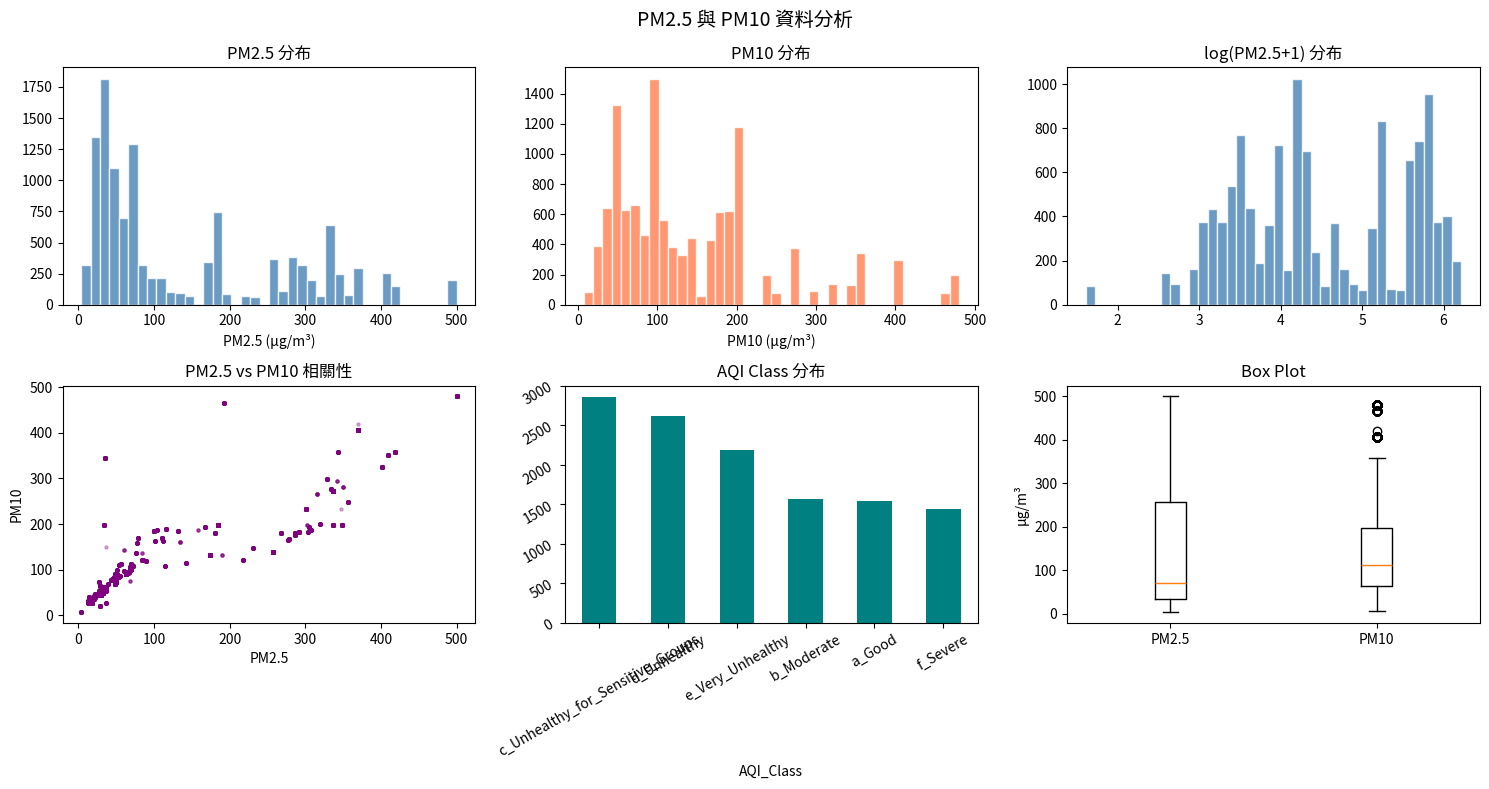

相關係數: 0.8415030885511865


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('PM2.5 與 PM10 資料分析', fontsize=14)

axes[0,0].hist(df['PM2.5'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('PM2.5 分布')
axes[0,0].set_xlabel('PM2.5 (μg/m³)')

axes[0,1].hist(df['PM10'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0,1].set_title('PM10 分布')
axes[0,1].set_xlabel('PM10 (μg/m³)')

axes[0,2].hist(np.log1p(df['PM2.5']), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,2].set_title('log(PM2.5+1) 分布')

axes[1,0].scatter(df['PM2.5'], df['PM10'], alpha=0.3, s=5, color='purple')
axes[1,0].set_xlabel('PM2.5')
axes[1,0].set_ylabel('PM10')
axes[1,0].set_title('PM2.5 vs PM10 相關性')

if 'AQI_Class' in df.columns:
    df['AQI_Class'].value_counts().plot(kind='bar', ax=axes[1,1], color='teal')
    axes[1,1].set_title('AQI Class 分布')
    axes[1,1].tick_params(rotation=30)

axes[1,2].boxplot([df['PM2.5'], df['PM10']], labels=['PM2.5', 'PM10'])
axes[1,2].set_title('Box Plot')
axes[1,2].set_ylabel('μg/m³')

plt.tight_layout()
plt.show()
print('相關係數:', df['PM2.5'].corr(df['PM10']))

In [8]:
CONFIG = {
    'img_size': 224,
    'batch_size': 32,
    'num_epochs': 30,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'train_ratio': 0.7,
    'val_ratio': 0.15,
    'use_log_transform': True,
    'num_workers': 2,
    'patience': 7,
}
print('設定:', CONFIG)

設定: {'img_size': 224, 'batch_size': 32, 'num_epochs': 30, 'lr': 0.0001, 'weight_decay': 0.0001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'use_log_transform': True, 'num_workers': 2, 'patience': 7}


In [9]:
class PM25Regressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.backbone(x)

model = PM25Regressor().to(device)
total = sum(p.numel() for p in model.parameters())
print(f'總參數: {total:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 122MB/s]


總參數: 11,106,282


In [10]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, labels).item() * len(imgs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(all_preds), np.concatenate(all_labels)

print('設定完成')

設定完成


In [11]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/AQI_Project'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoint 儲存至: {SAVE_DIR}')

Mounted at /content/drive
Checkpoint 儲存至: /content/drive/MyDrive/AQI_Project


In [12]:
import glob
import os

# 第一步：建立「檔名 → 完整路徑」的對照字典
print('掃描所有照片中，請稍等...')

ROOT = 'Air Pollution Image Dataset/Air Pollution Image Dataset'
all_images = glob.glob(f'{ROOT}/**/*.jpg', recursive=True)
all_images += glob.glob(f'{ROOT}/**/*.png', recursive=True)

# 建立字典：只用檔名當 key
filename_to_path = {}
for path in all_images:
    fname = os.path.basename(path)
    filename_to_path[fname] = path

print(f'共找到 {len(filename_to_path)} 張照片')

# 第二步：驗證 CSV 裡的檔名能否對應到
matched = sum(1 for fn in df['Filename'] if fn in filename_to_path)
print(f'CSV 共 {len(df)} 筆，能找到照片的有 {matched} 筆')

掃描所有照片中，請稍等...
共找到 12241 張照片
CSV 共 12240 筆，能找到照片的有 12240 筆


In [14]:
# 切分資料集
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n = len(df_shuffled)
n_train = int(n * CONFIG['train_ratio'])
n_val   = int(n * CONFIG['val_ratio'])

df_train = df_shuffled.iloc[:n_train]
df_val   = df_shuffled.iloc[n_train:n_train+n_val]
df_test  = df_shuffled.iloc[n_train+n_val:]

print(f'訓練集: {len(df_train)} 筆 | 驗證集: {len(df_val)} 筆 | 測試集: {len(df_test)} 筆')

# Transform 定義
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
class AQIDatasetV2(Dataset):
    def __init__(self, dataframe, filename_to_path, transform=None, use_log=True):
        self.df = dataframe.reset_index(drop=True)
        self.filename_to_path = filename_to_path
        self.transform = transform
        self.use_log = use_log

        # 只保留找得到照片的資料
        valid_mask = self.df['Filename'].apply(lambda fn: fn in filename_to_path)
        dropped = (~valid_mask).sum()
        if dropped > 0:
            print(f'  警告：{dropped} 筆找不到照片，已略過')
        self.df = self.df[valid_mask].reset_index(drop=True)
        print(f'  有效資料: {len(self.df)} 筆')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.filename_to_path[row['Filename']]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        pm25 = float(row['PM2.5'])
        pm10 = float(row['PM10'])
        if self.use_log:
            pm25 = np.log1p(pm25)
            pm10 = np.log1p(pm10)
        return img, torch.tensor([pm25, pm10], dtype=torch.float32)

# 重新建立 Dataset 和 DataLoader
print('重新建立 Dataset...')
train_dataset = AQIDatasetV2(df_train, filename_to_path, train_transform, CONFIG['use_log_transform'])
val_dataset   = AQIDatasetV2(df_val,   filename_to_path, val_transform,   CONFIG['use_log_transform'])
test_dataset  = AQIDatasetV2(df_test,  filename_to_path, val_transform,   CONFIG['use_log_transform'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f'每個 epoch 有 {len(train_loader)} 個 batch')

訓練集: 8568 筆 | 驗證集: 1836 筆 | 測試集: 1836 筆
重新建立 Dataset...
  有效資料: 8568 筆
  有效資料: 1836 筆
  有效資料: 1836 筆
每個 epoch 有 268 個 batch


In [ ]:
# 重新初始化模型和優化器
model = PM25Regressor().to(device)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0

print(f'重新開始訓練，共 {CONFIG["num_epochs"]} epochs...')

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_preds, val_labels = validate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:3d}/{CONFIG["num_epochs"]} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f'  ✅ 儲存最佳模型')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'⚠️  Early stopping at epoch {epoch}')
            break

print('訓練完成！')

重新開始訓練，共 30 epochs...


  0%|          | 0/268 [00:00<?, ?it/s]

In [ ]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
_, test_preds, test_labels = validate(model, test_loader, criterion, device)

if CONFIG['use_log_transform']:
    test_preds  = np.expm1(test_preds)
    test_labels = np.expm1(test_labels)

for i, name in enumerate(['PM2.5', 'PM10']):
    y_true, y_pred = test_labels[:, i], test_preds[:, i]
    print(f'【{name}】 MAE={mean_absolute_error(y_true, y_pred):.2f} | '
          f'RMSE={np.sqrt(mean_squared_error(y_true, y_pred)):.2f} | '
          f'R²={r2_score(y_true, y_pred):.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (name, color) in enumerate(zip(['PM2.5', 'PM10'], ['steelblue', 'coral'])):
    y_true, y_pred = test_labels[:, i], test_preds[:, i]
    axes[i].scatter(y_true, y_pred, alpha=0.3, s=8, color=color)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[i].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5)
    axes[i].set_title(f'{name}  MAE={mean_absolute_error(y_true, y_pred):.2f}, R²={r2_score(y_true, y_pred):.3f}')
    axes[i].set_xlabel('真實值 (μg/m³)')
    axes[i].set_ylabel('預測值 (μg/m³)')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

print('請上傳任意一張照片（jpg / png 皆可）...')
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(filename, 'wb') as f:
        f.write(content)

    result = predict_single_image(filename, model, device, CONFIG['use_log_transform'])

    img = Image.open(filename).convert('RGB')
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"預測結果\nPM2.5 = {result['PM2.5']:.1f} μg/m³\nPM10  = {result['PM10']:.1f} μg/m³",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()
    print(f'📊 {filename}')
    print(f'   PM2.5 = {result["PM2.5"]:.2f} μg/m³')
    print(f'   PM10  = {result["PM10"]:.2f} μg/m³')